In [9]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

from scipy.stats import randint

from sklearn import (
    preprocessing,
    ensemble,
    metrics,
    linear_model,
    feature_extraction,
    model_selection,
)

# Import Data

Here we import the data and set up the variables:
- `TARGET`
- `categorical_features`
- `numeric_features`

In [10]:
df = pd.read_csv("data/bank-additional-full.csv", sep=";")

# constant for referencing target
TARGET = "y"

# identify categorical and numeric features
categorical_features = df.select_dtypes(include=["object"]).columns
numeric_features = df.columns.difference(categorical_features)

# target is not a feature
categorical_features = categorical_features.drop(TARGET)

print("Categorical features:", categorical_features.tolist())
print("Numeric features:", numeric_features.tolist())

# make sure we didn't drop any variable
if len(df.columns) - 1 != len(categorical_features) + len(numeric_features):
    raise RuntimeError("Feature count doesn't add up")

df

Categorical features: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome']
Numeric features: ['age', 'campaign', 'cons.conf.idx', 'cons.price.idx', 'duration', 'emp.var.rate', 'euribor3m', 'nr.employed', 'pdays', 'previous']


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41183,73,retired,married,professional.course,no,yes,no,cellular,nov,fri,...,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,yes
41184,46,blue-collar,married,professional.course,no,no,no,cellular,nov,fri,...,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,no
41185,56,retired,married,university.degree,no,yes,no,cellular,nov,fri,...,2,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,no
41186,44,technician,married,professional.course,no,no,no,cellular,nov,fri,...,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,yes


# EDA

In [11]:
# change target to be numeric
df[TARGET] = df[TARGET].map({"yes": 1, "no": 0})

# remove `duration` from features
if "duration" in numeric_features:
    numeric_features = numeric_features.drop("duration")

## Get rid of duration

In [12]:
if "duration" in numeric_features:
    numeric_features = numeric_features.drop("duration")

## Balanced?

The dataset is not balanced, about 11% of it's are `TARGET = True`.

In [13]:
df[TARGET].mean()

np.float64(0.11265417111780131)

## Data Consistency

Here we check that all the object variables don't have any funny values values. They look alright:

In [14]:
for col in categorical_features:
    print(f"{col:<12}: {df[col].unique()}")

job         : ['housemaid' 'services' 'admin.' 'blue-collar' 'technician' 'retired'
 'management' 'unemployed' 'self-employed' 'unknown' 'entrepreneur'
 'student']
marital     : ['married' 'single' 'divorced' 'unknown']
education   : ['basic.4y' 'high.school' 'basic.6y' 'basic.9y' 'professional.course'
 'unknown' 'university.degree' 'illiterate']
default     : ['no' 'unknown' 'yes']
housing     : ['no' 'yes' 'unknown']
loan        : ['no' 'yes' 'unknown']
contact     : ['telephone' 'cellular']
month       : ['may' 'jun' 'jul' 'aug' 'oct' 'nov' 'dec' 'mar' 'apr' 'sep']
day_of_week : ['mon' 'tue' 'wed' 'thu' 'fri']
poutcome    : ['nonexistent' 'failure' 'success']


Now, we check the numeric features and see if we can find any strange behaviour here.

In [15]:
numeric_stats = pd.DataFrame(
    {
        "mean": df[numeric_features].mean().round(1),
        "min": df[numeric_features].min().round(1),
        "max": df[numeric_features].max().round(1),
        "var": df[numeric_features].var().round(1),
        "NaN?": df[numeric_features].isna().sum(),
    }
)
# Add a new column with descriptions for each statistic
numeric_stats["Description"] = [
    "Age of customer",
    "Total contacts in campaign (incl. last)",
    "Consumer confidence index (monthly)",
    "Consumer price index (monthly)",
    "Employment variation rate (quarterly)",
    "Euribor 3-month rate (daily)",
    "Number of employees (quarterly)",
    "Days since last campaign contact (999 = never)",
    "Number of contacts before this campaign",
]
numeric_stats

,mean,min,max,var,NaN?,Description
age,40.0,17.0,98.0,108.6,0,Age of customer
campaign,2.6,1.0,56.0,7.7,0,Total contacts in campaign (incl. last)
cons.conf.idx,-40.5,-50.8,-26.9,21.4,0,Consumer confidence index (monthly)
cons.price.idx,93.6,92.2,94.8,0.3,0,Consumer price index (monthly)
emp.var.rate,0.1,-3.4,1.4,2.5,0,Employment variation rate (quarterly)
euribor3m,3.6,0.6,5.0,3.0,0,Euribor 3-month rate (daily)
nr.employed,5167.0,4963.6,5228.1,5220.3,0,Number of employees (quarterly)
pdays,962.5,0.0,999.0,34935.7,0,Days since last campaign contact (999 = never)
previous,0.2,0.0,7.0,0.2,0,Number of contacts before this campaign


There are no NaN values. 

Alright so most of them seem fine. Here are some important points:
- variance of `age` is quite high in comparison to the range. But I won't do anything about it.
- also `pdays` has a very high variance. This has to do with the fact that no contact is codded by 999. we have to deal with that soon
 
 Minor nitpicks:
 - `age` 17-98 🧐: is allowed to telemarket underage children? Well, and what about telemarketing to 98 olds. Double well. Just a bit odd, but we have to trust that.
 - also a max `campaign` value of 56 means that one customer was called 56 times, which impressive
 - it's not quite clear for me what number of employees means. But ok, we don't have to know the unit.

# Baseline

We establish a baseline that we use for the rest of the notebook.

In [16]:
# split the data
SEED = 0

df_train_full, df_test = model_selection.train_test_split(
    df, test_size=0.2, random_state=SEED
)
df_train, df_val = model_selection.train_test_split(
    df_train_full, test_size=0.2 / 0.8, random_state=SEED
)

y_train_full = df_train_full.pop(TARGET)
y_train = df_train.pop(TARGET)
y_val = df_val.pop(TARGET)
y_test = df_test.pop(TARGET)

print(len(df_train), len(df_test), len(df_val))

24712 8238 8238


Baseline auc: 0.7900837084793536


<Figure size 800x600 with 0 Axes>

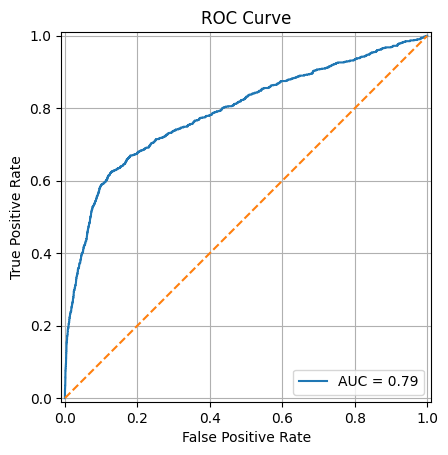

In [17]:
all_features = categorical_features.union(numeric_features)


def basic_linear_regression(
    df_train, y_train, df_val, features=all_features, seed=SEED
):
    # one-hot encoding
    dv = feature_extraction.DictVectorizer(sparse=False)
    X_train_unscaled = dv.fit_transform(df_train[features].to_dict(orient="records"))

    # scaling speeds up learning a lot
    scaler = preprocessing.StandardScaler()
    X_train = scaler.fit_transform(X_train_unscaled)

    # prepare val
    X_val_unscaled = dv.transform(df_val[features].to_dict(orient="records"))
    X_val = scaler.transform(X_val_unscaled)

    # train
    model = linear_model.LogisticRegression(random_state=seed)
    model.fit(X_train, y_train)

    # evaluate
    y_val_prob = model.predict_proba(X_val)[:, 1]

    return y_val_prob


y_val_prob = basic_linear_regression(df_train, y_train, df_val)
base_auc = metrics.roc_auc_score(y_val, y_val_prob)
print(f"Baseline auc: {base_auc}")

# Calculate the ROC curve
fpr, tpr, thresholds = metrics.roc_curve(y_val, y_val_prob)

# Plot the ROC curve
plt.figure(figsize=(8, 6))
metrics.RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=base_auc).plot()
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.grid(True)
plt.show()

# Feature Preparation

We have to deal with `pdays`.

We have 3 features dealing with and previous campaign:
- `poutcome`
- `previous`
- `pdays`

I want to deal with `pdays` high variance here and also that it's does not apply value of 999 might not be a good choice.

First let's see if how big pdays is normally. To make sure that 999 is not reached naturally.

In [18]:
df["pdays"].value_counts().sort_index()

pdays
0         15
1         26
2         61
3        439
4        118
5         46
6        412
7         60
8         18
9         64
10        52
11        28
12        58
13        36
14        20
15        24
16        11
17         8
18         7
19         3
20         1
21         2
22         3
25         1
26         1
27         1
999    39673
Name: count, dtype: int64

We can conclude that 999 is not accidentally the amount of days since the previous contact. It might be better to map 999 -> -1 to have this flag value out of the data range.

However, there is still something fishy about 'pdays'.

To ee this firs note that 
`poutcome` and `previous` agree in the sense that:

    (poutcome == nonexistent) <=> (previous == 0)

In [19]:
crosstab = pd.crosstab(df["poutcome"] == "nonexistent", df["previous"] == 0)
crosstab

previous,False,True
poutcome,,
False,5625,0
True,0,35563


However for `pdays` we have  inconsistencies

In [20]:
crosstab = pd.crosstab(df["poutcome"], df["pdays"] == -1)
crosstab

pdays,False
poutcome,
failure,4252
nonexistent,35563
success,1373


There are 4110 rows for which `pdays = -1` but `poutcome == failure`. That shouldn't happen though.

Let's see if we can find any better flag values for pdays and also default values for when `poutcome == 'failure'`

In [21]:
df_val.isna().sum()

age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
dtype: int64

In [22]:
def feature_preparation_pdays(missing_flag, default_value):
    all_features = categorical_features.union(numeric_features)
    # Create copies of the DataFrames to avoid modifying the originals
    df_train_copy = df_train[all_features].copy()
    df_val_copy = df_val[all_features].copy()

    # change 999 to missing flag
    df_train_copy["pdays"] = df_train_copy["pdays"].apply(
        lambda x: missing_flag if x == 999 else x
    )
    df_val_copy["pdays"] = df_val_copy["pdays"].apply(
        lambda x: missing_flag if x == 999 else x
    )

    # set default_value when pdays == missing_flag and poutcome == failure
    df_train_copy.loc[
        (df_train_copy["pdays"] == missing_flag)
        & (df_train_copy["poutcome"] == "failure"),
        "pdays",
    ] = default_value
    df_val_copy.loc[
        (df_val_copy["pdays"] == missing_flag) & (df_val_copy["poutcome"] == "failure"),
        "pdays",
    ] = default_value

    y_val_prob = basic_linear_regression(
        df_train_copy,
        y_train,
        df_val_copy,
    )

    return metrics.roc_auc_score(y_val, y_val_prob)


for missing_flag in [-1, 999]:
    for default_value in [-1, 0, 1, 10, 100]:
        _auc = feature_preparation_pdays(missing_flag, default_value)
        print(
            f"missing: {missing_flag}, default: {default_value} -> {_auc:.3f}, (relative to base: {_auc/base_auc*100:.0f}%)"
        )

missing: -1, default: -1 -> 0.790, (relative to base: 100%)
missing: -1, default: 0 -> 0.791, (relative to base: 100%)
missing: -1, default: 1 -> 0.790, (relative to base: 100%)
missing: -1, default: 10 -> 0.791, (relative to base: 100%)
missing: -1, default: 100 -> 0.790, (relative to base: 100%)
missing: 999, default: -1 -> 0.791, (relative to base: 100%)
missing: 999, default: 0 -> 0.791, (relative to base: 100%)
missing: 999, default: 1 -> 0.791, (relative to base: 100%)
missing: 999, default: 10 -> 0.791, (relative to base: 100%)
missing: 999, default: 100 -> 0.790, (relative to base: 100%)


So apparently it doesn't matter. We will just leave the `pdays` as it is then.

## Feature selection

We will see if we can cull down the number of features and if this improves our score.

In [23]:
n_folds = 5


def features_score(features):
    kfold = model_selection.KFold(n_splits=n_folds, shuffle=True, random_state=SEED)
    scores = []
    for train_idx, val_idx in kfold.split(df_train_full):
        df_train_fold, df_val_fold = (
            df_train_full.iloc[train_idx],
            df_train_full.iloc[val_idx],
        )
        y_train_fold, y_val_fold = (
            y_train_full.iloc[train_idx],
            y_train_full.iloc[val_idx],
        )
        y_val_prob = basic_linear_regression(
            df_train_fold, y_train_fold, df_val_fold, features=features, seed=SEED
        )
        scores.append(metrics.roc_auc_score(y_val_fold, y_val_prob))
    return np.mean(scores) / base_auc


current_features = all_features.copy()
feature_importance = {}

while current_features.size > 1:
    feature_score_map = {
        feature: features_score(current_features.drop(feature))
        for feature in current_features
    }
    # Sort the dictionary by value and get the worst feature (with highest AUC after it got dropped)
    worst_feature = max(feature_score_map, key=feature_score_map.get)
    best_feature = min(feature_score_map, key=feature_score_map.get)
    feature_importance[worst_feature] = feature_score_map[worst_feature]
    current_features = current_features.drop(worst_feature)
    print(
        f"worst of {current_features.size} features: {worst_feature} -> {feature_score_map[worst_feature]*100:.2f}% of base AUC"
    )

KeyboardInterrupt: 

<Axes: >

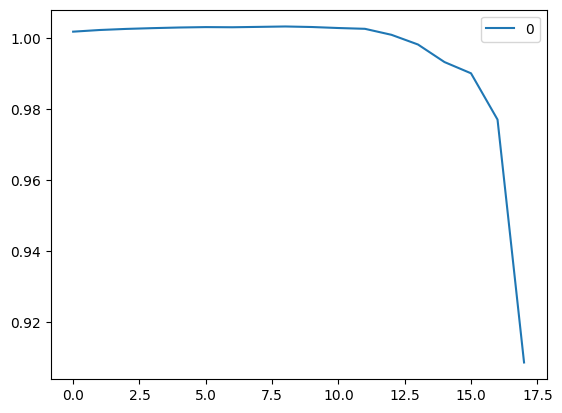

In [ ]:
sns.lineplot(feature_importance.values())

In [24]:
mini_features = [
    "cons.price.idx",
    "contact",
    "emp.var.rate",
    "euribor3m",
    "month",
    "pdays",
    "previous",
]

# Model Training

## Tuning Linear Model

In [25]:
# one-hot encoding
dv = feature_extraction.DictVectorizer(sparse=False)
X_train = dv.fit_transform(df_train[mini_features].to_dict(orient="records"))

# scaling
scaler = preprocessing.StandardScaler().fit(X_train)
X_train_scaled = scaler.transform(X_train)

X_val = dv.transform(df_val[mini_features].to_dict(orient="records"))
X_val_scaled = scaler.transform(X_val)

log_reg = linear_model.LogisticRegression()

param_grid = {
    "C": [0.001, 0.01, 0.1, 1, 10, 100],
    "penalty": ["l1", "l2"],
    "solver": ["liblinear", "saga"],  # both support L1
    "max_iter": [200, 500, 1_000, 2_000],
}

grid = model_selection.GridSearchCV(
    estimator=log_reg,
    param_grid=param_grid,
    cv=5,
    scoring="roc_auc",  # or f1, roc_auc, etc.
    n_jobs=-1,
)

grid.fit(X_train_scaled, y_train)

print("Best params:", grid.best_params_)
print(f"Best score: {grid.best_score_} ({grid.best_score_/base_auc*100:.1f}%)")

Best params: {'C': 10, 'max_iter': 1000, 'penalty': 'l2', 'solver': 'saga'}
Best score: 0.7924796542611385 (100.3%)


## Tuning Tree-based model

In [144]:
# one-hot encoding
dv = feature_extraction.DictVectorizer(sparse=False)
X_train_full_unscaled = dv.fit_transform(
    df_train_full[mini_features].to_dict(orient="records")
)

# scaling
scaler = preprocessing.StandardScaler().fit(X_train_full_unscaled)
X_train_full = scaler.transform(X_train_full_unscaled)


rf = ensemble.RandomForestClassifier(random_state=SEED, n_jobs=-1)

param_dist = {
    "n_estimators": randint(100, 800),  # trees
    "max_depth": randint(3, 50),  # depth
    "min_samples_split": randint(2, 20),
    "min_samples_leaf": randint(1, 20),
    "max_features": ["sqrt", "log2", 0.2, 0.5, None],
    "bootstrap": [True, False],
    "class_weight": [None, "balanced", "balanced_subsample"],
}

search = model_selection.RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=80,
    scoring="roc_auc",
    cv=5,
    verbose=1,
    random_state=42,
    n_jobs=-1,
)

search.fit(X_train_full, y_train_full)

print("Best params:", search.best_params_)
print(f"Best score: {search.best_score_} ({search.best_score_/base_auc*100:.1f}%)")
best_rf = search.best_estimator_

Fitting 5 folds for each of 80 candidates, totalling 400 fits
Best params: {'bootstrap': True, 'class_weight': 'balanced', 'max_depth': 8, 'max_features': 0.5, 'min_samples_leaf': 12, 'min_samples_split': 13, 'n_estimators': 439}
Best score: 0.799662428774665 (101.2%)


# Validation

Test auc: 0.8144800577922533 (103.09%)


<Figure size 800x600 with 0 Axes>

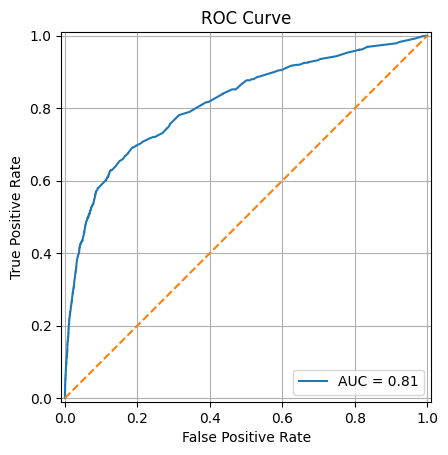

In [26]:
# one-hot encoding
dv = feature_extraction.DictVectorizer(sparse=False)
X_train_full_unscaled = dv.fit_transform(
    df_train_full[mini_features].to_dict(orient="records")
)

# scaling
scaler = preprocessing.StandardScaler()
X_train_full = scaler.fit_transform(X_train_full_unscaled)

# train
rf = ensemble.RandomForestClassifier(
    random_state=SEED,
    n_jobs=-1,
    bootstrap=True,
    class_weight="balanced",
    max_depth=8,
    max_features=0.5,
    min_samples_leaf = 12,
    min_samples_split=13,
    n_estimators=439,
)

rf.fit(X_train_full, y_train_full)



# evaluate
X_test = scaler.transform(dv.transform(df_test[mini_features].to_dict(orient="records")))
y_test_prob = rf.predict_proba(X_test)[:, 1]


test_auc = metrics.roc_auc_score(y_test, y_test_prob)
print(f"Test auc: {test_auc} ({test_auc/base_auc*100:.2f}%)")

# Calculate the ROC curve
fpr, tpr, thresholds = metrics.roc_curve(y_test, y_test_prob)

# Plot the ROC curve
plt.figure(figsize=(8, 6))
metrics.RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=test_auc).plot()
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.grid(True)
plt.show()

In [32]:
df_test[mini_features].iloc[0]

cons.price.idx      93.918
contact           cellular
emp.var.rate           1.4
euribor3m            4.957
month                  jul
pdays                  999
previous                 0
Name: 15500, dtype: object